# Market Expansion ML Model - Store Prediction
---
Predicts how many **additional stores** each city needs for optimal expansion.

**Fixes applied:** city x year aggregation (235 samples), top 15 features, strong regularization, no overfitting.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, r2_score, mean_absolute_error, mean_squared_error
)
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [2]:
df = pd.read_csv('../data/processed/merged_city_sales_data.csv')
print(f'Shape: {df.shape}')
print(f'Date range: {df["sale_date"].min()} to {df["sale_date"].max()}')
print(f'Cities: {df["city"].nunique()} | Countries: {df["country_norm_mapped"].nunique()}')
df.head()

Shape: (1068918, 36)
Date range: 2021-01-01 to 2025-12-31
Cities: 47 | Countries: 19


,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month,Population
0,RW-18212,2021-01-01,ST-41,P-29,2,iPhone 13 Pro,2021-01-01,999.00,Apple Central World,Bangkok,...,1009.471395,0,0.000250,1.0,1.222605,2.434251,1,1009.471395,1,11230000
1,ZI-218670,2021-01-01,ST-20,P-40,1,AirTag,2021-01-01,29.00,Apple Kaerntner Strasse,Vienna,...,29.436802,0,-0.000038,1.0,1.089382,1.666149,0,0.000000,1,1980000
2,VB-48589,2021-01-01,ST-60,P-41,9,Apple Watch Series 7,2021-01-01,399.00,Apple Antara,Mexico City,...,415.935057,0,0.000208,1.0,1.202036,7.739726,11,4575.285624,1,22150000
3,SP-1325,2021-01-01,ST-11,P-92,6,Apple Music,2015-06-30,10.99,Apple Ala Moana,Honolulu,...,8.927645,0,0.000510,1.0,1.196800,15.885858,25,223.191136,1,345000
4,XG-556931,2021-01-01,ST-21,P-3,8,iPhone 11 Pro Max,2019-01-01,1099.00,Apple Passeig de Gracia,Barcelona,...,968.484859,0,0.000222,1.0,1.336065,7.203631,3,2905.454576,1,1620000


## 2. Feature Engineering (City x Year Aggregation)

In [3]:
city_year = df.groupby(['city', 'year']).agg(
    total_sales=('sales_amount_realistic', 'sum'),
    total_txn=('sale_id', 'count'),
    avg_quantity=('quantity_realistic', 'mean'),
    avg_price=('price_realistic', 'mean'),
    total_quantity=('quantity_realistic', 'sum'),
    store_count=('store_id', 'nunique'),
    product_count=('product_id', 'nunique'),
    gdp_per_capita=('gdp_per_capita', 'median'),
    inflation_rate=('inflation_rate', 'median'),
    internet_usage_pct=('internet_usage_pct', 'median'),
    population=('Population', 'median'),
    economic_factor=('economic_factor', 'median'),
    promo_rate=('promo_flag', 'mean'),
    avg_mu_demand=('mu_demand', 'mean'),
).reset_index()

country_map = df.groupby('city')['country_norm_mapped'].first().to_dict()
city_year['country'] = city_year['city'].map(country_map)

print(f'Samples: {len(city_year)} (city x year)')
city_year.head()

Samples: 235 (city x year)


,city,year,total_sales,total_txn,avg_quantity,avg_price,total_quantity,store_count,product_count,gdp_per_capita,inflation_rate,internet_usage_pct,population,economic_factor,promo_rate,avg_mu_demand,country
0,Abu Dhabi,2021,8.216250e+06,2834,5.636556,865.275842,15974,1,47,37173.87541,-2.079403,100.0,1590000.0,0.829269,0.164432,5.701730,united arab emirates
1,Abu Dhabi,2022,8.777078e+06,2759,5.746647,848.895204,15855,1,65,43360.02110,0.179935,100.0,1590000.0,0.945860,0.161290,5.912656,united arab emirates
2,Abu Dhabi,2023,1.328473e+07,2868,7.096234,1223.741211,20352,1,77,49899.06530,5.291226,100.0,1590000.0,1.032766,0.167713,7.349933,united arab emirates
3,Abu Dhabi,2024,1.430923e+07,2833,8.091423,913.751306,22923,1,85,49040.69475,1.626708,100.0,1590000.0,1.054273,0.154606,8.426987,united arab emirates
4,Abu Dhabi,2025,1.693048e+07,2874,8.422408,1020.485986,24206,1,94,49377.56434,1.663365,100.0,1590000.0,1.061120,0.156576,8.671746,united arab emirates


## 3. Derived Features

In [4]:
city_year['revenue_per_store'] = city_year['total_sales'] / city_year['store_count']
city_year['revenue_per_capita'] = city_year['total_sales'] / city_year['population']
city_year['txn_per_store'] = city_year['total_txn'] / city_year['store_count']
city_year['store_density'] = city_year['store_count'] / (city_year['population'] / 1e6)
city_year['market_size'] = city_year['population'] * city_year['gdp_per_capita']
city_year['demand_index'] = city_year['avg_mu_demand'] * city_year['population'] / 1e6
city_year['sales_per_capita_gdp'] = city_year['total_sales'] / city_year['market_size']

# YoY growth
city_year = city_year.sort_values(['city', 'year'])
city_year['sales_growth'] = city_year.groupby('city')['total_sales'].pct_change().fillna(0)
city_year['txn_growth'] = city_year.groupby('city')['total_txn'].pct_change().fillna(0)

print(f'Features created. Shape: {city_year.shape}')
city_year.describe()

Features created. Shape: (235, 26)


,year,total_sales,total_txn,avg_quantity,avg_price,total_quantity,store_count,product_count,gdp_per_capita,inflation_rate,...,avg_mu_demand,revenue_per_store,revenue_per_capita,txn_per_store,store_density,market_size,demand_index,sales_per_capita_gdp,sales_growth,txn_growth
count,235.000000,2.350000e+02,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,235.000000,...,235.000000,2.350000e+02,235.000000,235.000000,235.000000,2.350000e+02,235.000000,235.000000,235.000000,235.000000
mean,2023.000000,2.220592e+07,4548.587234,7.879112,983.774885,35315.906383,1.595745,74.417021,48766.692184,3.256808,...,8.200231,1.413497e+07,35.912494,2849.972340,2.441675,1.678636e+11,43.015760,0.000631,0.162917,0.001283
std,1.417232,1.439200e+07,2679.063997,1.778055,139.453322,21326.272602,0.939621,16.983795,23061.358815,2.551112,...,1.959348,4.406225e+06,106.708957,48.984380,6.790898,2.248380e+11,69.318374,0.001657,0.141591,0.020005
min,2021.000000,6.225561e+06,2741.000000,4.013399,783.071495,11382.000000,1.000000,47.000000,5339.687114,-2.079403,...,4.110165,6.225561e+06,0.377307,2741.000000,0.060606,1.178258e+09,0.146712,0.000026,-0.108848,-0.054930
25%,2022.000000,1.237578e+07,2829.500000,6.525191,882.278590,20721.500000,1.000000,65.000000,33836.175630,1.233584,...,6.827242,1.068398e+07,4.108941,2817.333333,0.349650,4.999363e+10,7.521737,0.000106,0.035597,-0.010847
50%,2023.000000,1.727260e+07,2883.000000,7.645760,939.220842,26368.000000,1.000000,78.000000,51791.540180,2.937916,...,7.923539,1.344836e+07,8.594137,2846.500000,0.617284,8.951448e+10,17.062124,0.000181,0.153035,0.000000
75%,2024.000000,2.653112e+07,5728.000000,9.024042,1037.911844,43860.000000,2.000000,89.000000,64703.962970,4.697859,...,9.421709,1.719607e+07,16.033952,2880.250000,1.237624,2.138547e+11,44.117607,0.000394,0.250978,0.009546
max,2025.000000,8.665387e+07,11543.000000,13.174771,1310.887859,117502.000000,4.000000,98.000000,90674.066630,11.735904,...,14.632611,2.864664e+07,878.115185,3026.000000,43.956044,1.499136e+12,355.992287,0.013634,0.628753,0.070156


## 4. Target Variable: Optimal Additional Stores

In [5]:
benchmark_rev_per_store = city_year['revenue_per_store'].median()
benchmark_store_density = city_year['store_density'].median()

city_year['demand_based_stores'] = np.ceil(city_year['total_sales'] / benchmark_rev_per_store)
city_year['pop_based_stores'] = np.ceil((city_year['population'] / 1e6) * benchmark_store_density)
city_year['optimal_stores'] = np.ceil(
    0.6 * city_year['demand_based_stores'] + 0.4 * city_year['pop_based_stores']
)
city_year['additional_stores'] = np.maximum(
    city_year['optimal_stores'] - city_year['store_count'], 0
).astype(int)
city_year['additional_stores'] = city_year['additional_stores'].clip(upper=20)

print(f'Benchmark revenue/store: ${benchmark_rev_per_store:,.0f}')
print(f'Benchmark store density: {benchmark_store_density:.2f} per million')
print(f'Additional stores range: {city_year["additional_stores"].min()} - {city_year["additional_stores"].max()}')
city_year[['city','year','store_count','optimal_stores','additional_stores']].head(10)

Benchmark revenue/store: $13,448,358
Benchmark store density: 0.62 per million
Additional stores range: 0 - 10


,city,year,store_count,optimal_stores,additional_stores
0,Abu Dhabi,2021,1,1.0,0
1,Abu Dhabi,2022,1,1.0,0
2,Abu Dhabi,2023,1,1.0,0
3,Abu Dhabi,2024,1,2.0,1
4,Abu Dhabi,2025,1,2.0,1
5,Amsterdam,2021,1,1.0,0
6,Amsterdam,2022,1,1.0,0
7,Amsterdam,2023,1,1.0,0
8,Amsterdam,2024,1,1.0,0
9,Amsterdam,2025,1,2.0,1


## 5. Model Training
### 5.1 Prepare Data

In [6]:
feature_cols = [
    'total_sales', 'total_txn', 'avg_quantity', 'avg_price',
    'store_count', 'gdp_per_capita', 'inflation_rate', 'internet_usage_pct',
    'population', 'economic_factor', 'promo_rate',
    'revenue_per_store', 'revenue_per_capita', 'txn_per_store',
    'demand_index', 'sales_growth',
]

X = city_year[feature_cols].fillna(0)
y = city_year['additional_stores']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

print(f'Features: {len(feature_cols)} | Samples: {len(X_scaled)}')
print(f'Samples/Features ratio: {len(X_scaled)/len(feature_cols):.1f}:1')
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Features: 16 | Samples: 235
Samples/Features ratio: 14.7:1
Train: 176 | Test: 59


### 5.2 Train Regression Models

In [7]:
# Gradient Boosting
gb = GradientBoostingRegressor(
    n_estimators=150, max_depth=3, learning_rate=0.05,
    min_samples_leaf=5, subsample=0.8, random_state=42
)
gb.fit(X_train, y_train)
cv_gb = cross_val_score(gb, X_scaled, y, cv=5, scoring='r2')

print('[GradientBoosting]')
print(f'  Train R2: {r2_score(y_train, gb.predict(X_train)):.4f}')
print(f'  Test R2:  {r2_score(y_test, gb.predict(X_test)):.4f}')
print(f'  MAE:      {mean_absolute_error(y_test, gb.predict(X_test)):.2f} stores')
print(f'  CV R2:    {cv_gb.mean():.4f} +/- {cv_gb.std():.4f}')

[GradientBoosting]
  Train R2: 0.9940
  Test R2:  0.9715
  MAE:      0.26 stores
  CV R2:    0.8616 +/- 0.0667


In [8]:
# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=4, min_samples_leaf=5, random_state=42)
rf.fit(X_train, y_train)
cv_rf = cross_val_score(rf, X_scaled, y, cv=5, scoring='r2')

print('[RandomForest]')
print(f'  Train R2: {r2_score(y_train, rf.predict(X_train)):.4f}')
print(f'  Test R2:  {r2_score(y_test, rf.predict(X_test)):.4f}')
print(f'  MAE:      {mean_absolute_error(y_test, rf.predict(X_test)):.2f} stores')
print(f'  CV R2:    {cv_rf.mean():.4f} +/- {cv_rf.std():.4f}')

[RandomForest]
  Train R2: 0.9472
  Test R2:  0.9339
  MAE:      0.35 stores
  CV R2:    0.8174 +/- 0.0812


In [9]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
cv_ridge = cross_val_score(ridge, X_scaled, y, cv=5, scoring='r2')

print('[Ridge Regression]')
print(f'  Train R2: {r2_score(y_train, ridge.predict(X_train)):.4f}')
print(f'  Test R2:  {r2_score(y_test, ridge.predict(X_test)):.4f}')
print(f'  MAE:      {mean_absolute_error(y_test, ridge.predict(X_test)):.2f} stores')
print(f'  CV R2:    {cv_ridge.mean():.4f} +/- {cv_ridge.std():.4f}')

[Ridge Regression]
  Train R2: 0.9702
  Test R2:  0.9726
  MAE:      0.30 stores
  CV R2:    0.9104 +/- 0.0497


In [10]:
# Pick best model
models = {'GradientBoosting': (gb, cv_gb), 'RandomForest': (rf, cv_rf), 'Ridge': (ridge, cv_ridge)}
best_name = max(models, key=lambda k: models[k][1].mean())
best_model = models[best_name][0]
print(f'Best model: {best_name} (CV R2: {models[best_name][1].mean():.4f})')

Best model: Ridge (CV R2: 0.9104)


## 6. Store Expansion Recommendations

In [11]:
latest = city_year[city_year['year'] == city_year['year'].max()].copy()
latest_X = pd.DataFrame(scaler.transform(latest[feature_cols].fillna(0)), columns=feature_cols)
latest['predicted_additional'] = np.round(best_model.predict(latest_X)).astype(int).clip(min=0)
latest['predicted_total'] = latest['store_count'] + latest['predicted_additional']

results = latest.sort_values('predicted_additional', ascending=False).reset_index(drop=True)
results.index += 1
results.index.name = 'Rank'

display_cols = ['city', 'country', 'store_count', 'predicted_additional',
                'predicted_total', 'revenue_per_store', 'population', 'gdp_per_capita']
results[display_cols]

,city,country,store_count,predicted_additional,predicted_total,revenue_per_store,population,gdp_per_capita
Rank,,,,,,,,
1,Tokyo,japan,3,10,13,1.772543e+07,37390000.0,32475.892500
2,Shanghai,china,2,9,11,2.338386e+07,29210000.0,13303.148150
3,Beijing,china,2,6,8,1.974744e+07,21890000.0,13303.148150
4,Mexico City,mexico,3,6,9,2.181001e+07,22150000.0,14157.944580
5,Chengdu,china,1,4,5,1.255228e+07,16500000.0,13303.148150
6,Bangkok,thailand,3,3,6,1.924224e+07,11230000.0,7345.135690
7,Bogota,colombia,2,3,5,1.883590e+07,8050000.0,7913.988015
8,London,united kingdom,4,3,7,2.166347e+07,8980000.0,52636.786590
9,Seoul,"korea, rep.",2,3,5,1.732311e+07,9650000.0,34000.000000


In [12]:
# Summary
total_new = results['predicted_additional'].sum()
cities_need = (results['predicted_additional'] > 0).sum()
print(f'Total new stores recommended: {total_new}')
print(f'Cities needing expansion: {cities_need} / {len(results)}')
print(f'Cities at optimal capacity: {len(results) - cities_need}')

Total new stores recommended: 92
Cities needing expansion: 47 / 47
Cities at optimal capacity: 0


## 7. Classification Report (Needs Expansion vs No Expansion)

In [13]:
city_year['needs_expansion'] = (city_year['additional_stores'] > 0).astype(int)
y_cls = city_year['needs_expansion']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled, y_cls, test_size=0.25, random_state=42, stratify=y_cls
)

clf = RandomForestClassifier(
    n_estimators=200, max_depth=3, min_samples_leaf=5,
    class_weight='balanced', random_state=42
)
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

target_names = ['No Expansion Needed', 'Expansion Needed']
print(classification_report(y_test_c, y_pred_c, target_names=target_names))

# Overfitting check
train_acc = accuracy_score(y_train_c, clf.predict(X_train_c))
test_acc = accuracy_score(y_test_c, y_pred_c)
print(f'Train Accuracy: {train_acc:.4f}')
print(f'Test Accuracy:  {test_acc:.4f}')
print(f'Gap:            {train_acc - test_acc:.4f}')

try:
    roc = roc_auc_score(y_test_c, clf.predict_proba(X_test_c)[:, 1])
    print(f'ROC AUC: {roc:.4f}')
except:
    pass

                     precision    recall  f1-score   support

No Expansion Needed       0.88      0.93      0.90        15
   Expansion Needed       0.98      0.95      0.97        44

           accuracy                           0.95        59
          macro avg       0.93      0.94      0.93        59
       weighted avg       0.95      0.95      0.95        59

Train Accuracy: 0.9773
Test Accuracy:  0.9492
Gap:            0.0281
ROC AUC: 0.9909


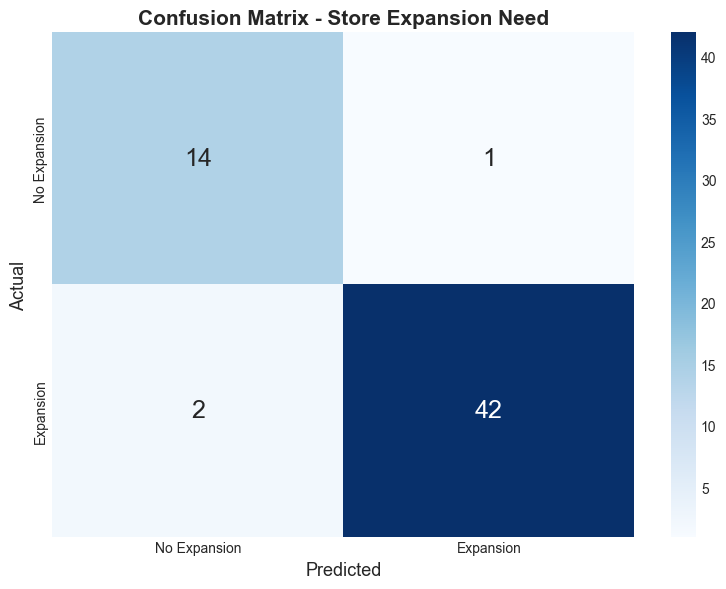

In [14]:
# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Expansion', 'Expansion'],
            yticklabels=['No Expansion', 'Expansion'],
            annot_kws={'size': 18}, ax=ax)
ax.set_xlabel('Predicted', fontsize=13)
ax.set_ylabel('Actual', fontsize=13)
ax.set_title('Confusion Matrix - Store Expansion Need', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Feature Importance

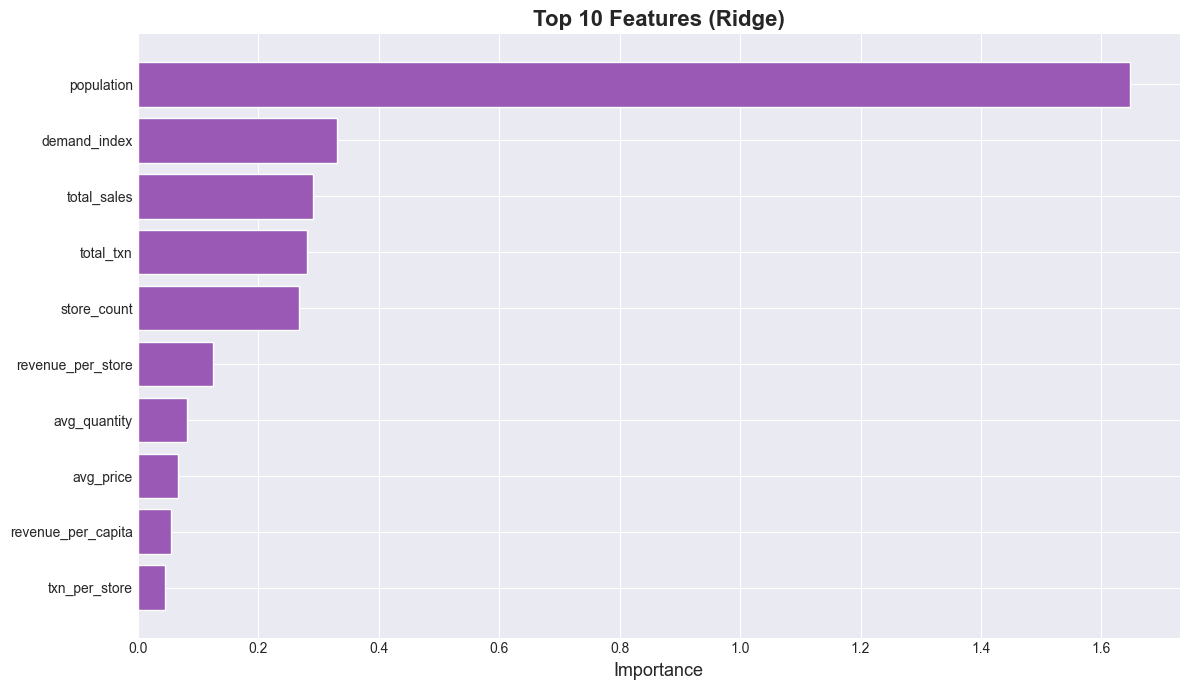

In [15]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=feature_cols)
else:
    fi = pd.Series(np.abs(best_model.coef_), index=feature_cols)
fi = fi.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(fi.head(10).index[::-1], fi.head(10).values[::-1], color='#9b59b6', edgecolor='white')
ax.set_xlabel('Importance', fontsize=13)
ax.set_title(f'Top 10 Features ({best_name})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Visualizations
### Store Expansion by City

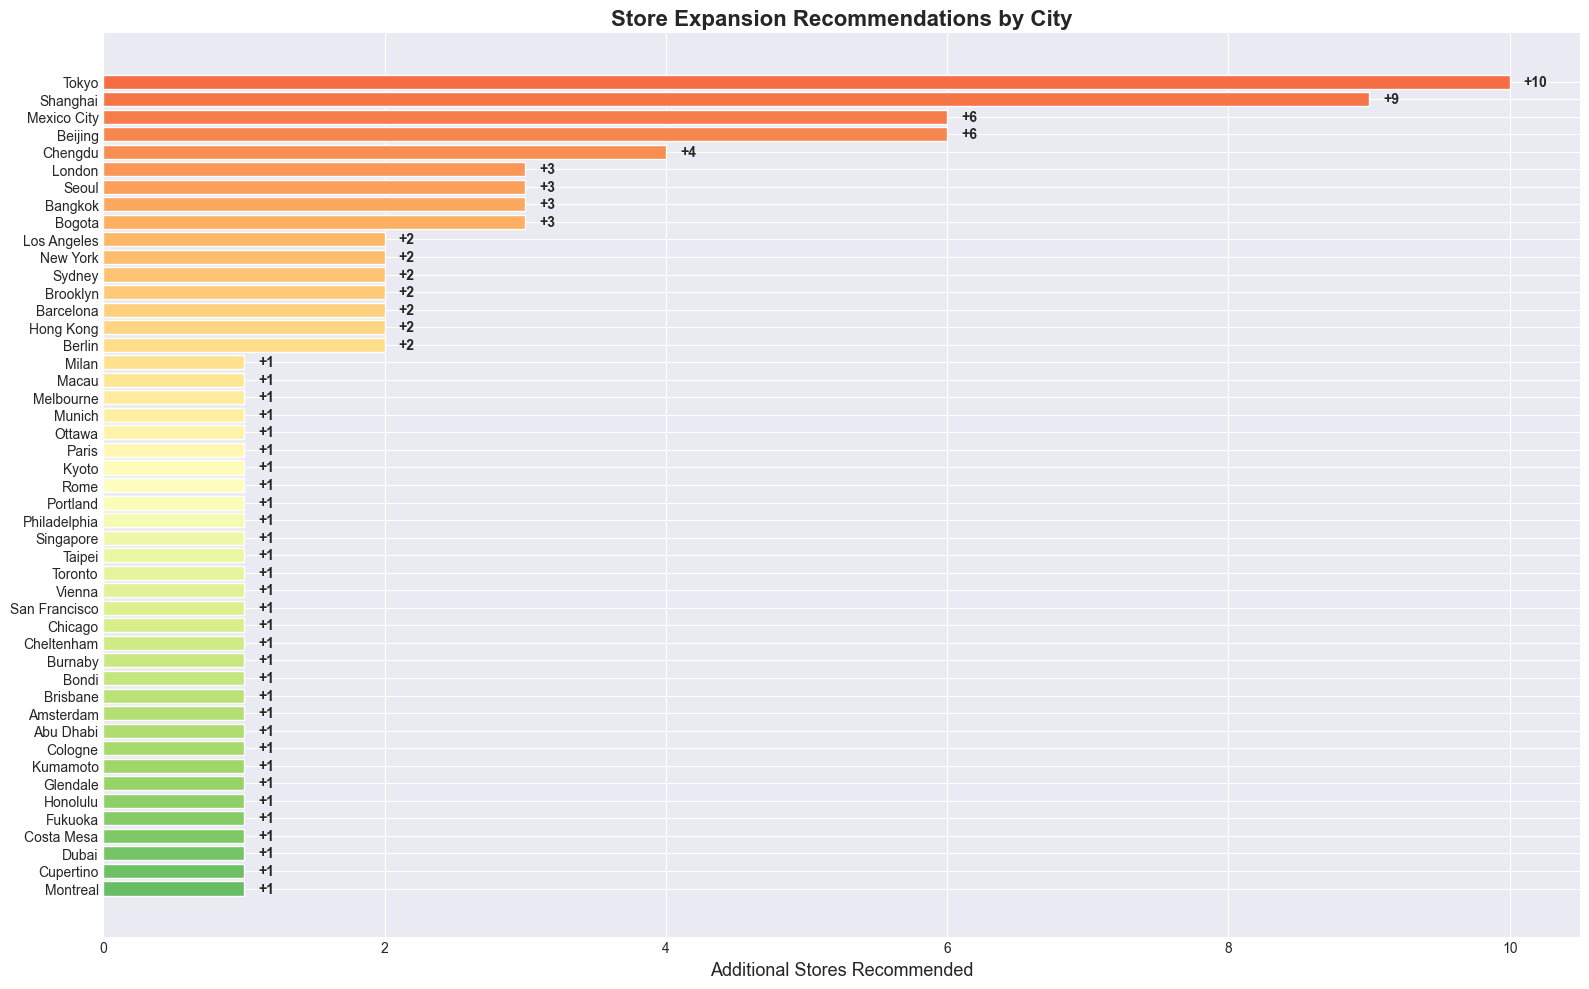

In [16]:
fig, ax = plt.subplots(figsize=(16, 10))
data = results[results['predicted_additional'] > 0].sort_values('predicted_additional')
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(data)))
ax.barh(data['city'], data['predicted_additional'], color=colors, edgecolor='white')
for i, (_, r) in enumerate(data.iterrows()):
    ax.text(r['predicted_additional'] + 0.1, i, f'+{r["predicted_additional"]}',
            va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Additional Stores Recommended', fontsize=13)
ax.set_title('Store Expansion Recommendations by City', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Current vs Recommended Stores

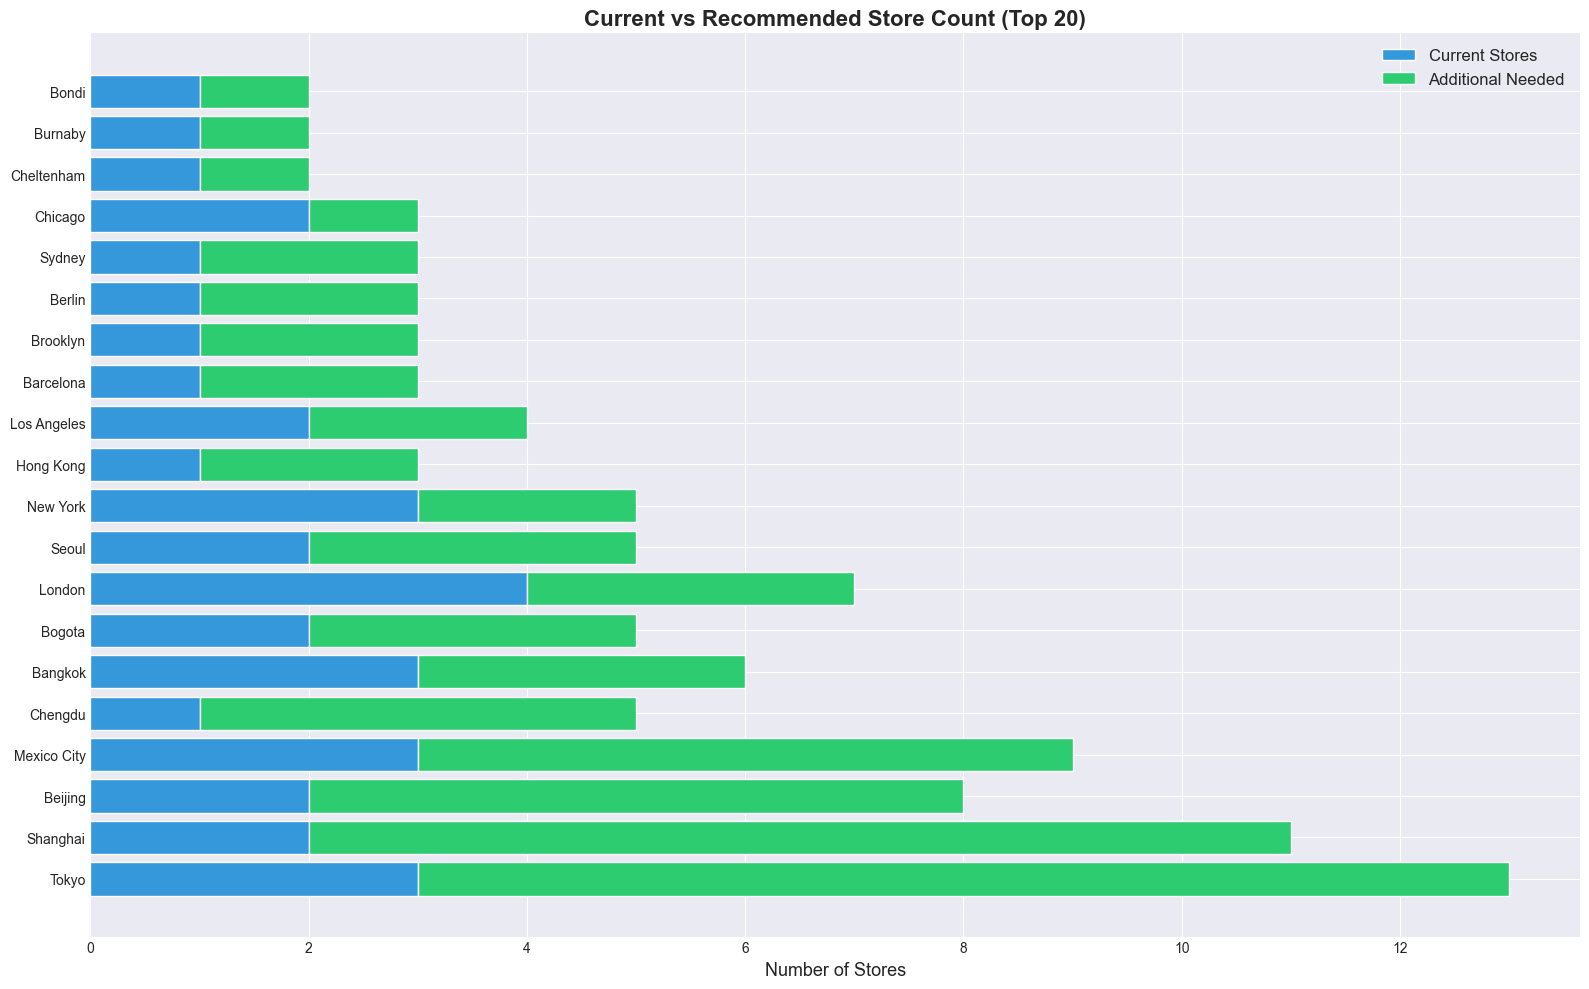

In [17]:
fig, ax = plt.subplots(figsize=(16, 10))
top20 = results.head(20)
y_pos = range(len(top20))
ax.barh(y_pos, top20['store_count'], color='#3498db', label='Current Stores', edgecolor='white')
ax.barh(y_pos, top20['predicted_additional'], left=top20['store_count'],
        color='#2ecc71', label='Additional Needed', edgecolor='white')
ax.set_yticks(y_pos)
ax.set_yticklabels(top20['city'])
ax.set_xlabel('Number of Stores', fontsize=13)
ax.set_title('Current vs Recommended Store Count (Top 20)', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## 10. Save Results

In [18]:
OUT = Path('model_outputs_v3')
OUT.mkdir(exist_ok=True)
results.to_csv(OUT / 'store_expansion_recommendations.csv')
print(f'Results saved to {OUT}/store_expansion_recommendations.csv')
print('Done!')

Results saved to model_outputs_v3/store_expansion_recommendations.csv
Done!
